In [1]:
import pandas as pd
import sqlalchemy as sa
import pyodbc as pyodbc

In [2]:
server = "localhost\\MSSQLSERVER2019"
database = "DEP2"
driver = "ODBC Driver 17 for SQL Server"

engine = sa.create_engine(
    f"mssql+pyodbc://@{server}/{database}?driver={driver}&trusted_connection=yes&TrustServerCertificate=yes"
)

with engine.connect() as conn:
    query = """SELECT *
    FROM FactLecture
    JOIN DimDate ON FactLecture.DateKey = DimDate.DateKey
    JOIN DimTime dt_from ON FactLecture.FromTimeKey = dt_from.TimeKey
    JOIN DimTime dt_until ON FactLecture.UntilTimeKey = dt_until.TimeKey
    JOIN DimClass ON FactLecture.ClassKey = DimClass.ClassKey
    JOIN DimSubgroup ON FactLecture.SubgroupKey = DimSubgroup.SubgroupKey
    JOIN DimActivity ON FactLecture.ActivityKey = DimActivity.ActivityKey
    WHERE FactLecture.DateKey < CONVERT(VARCHAR, GETDATE(), 112)
      AND AttendanceRate IS NOT NULL
      AND DimSubgroup.ProgramName LIKE 'PBA-TIN%'""" # Only past TIN lectures - other richtingen only have real wifi/roster coverage for a 3-week window, not the full year
    df_fact_lecture = pd.read_sql(query, conn)

df_fact_lecture

,LectureID,DateKey,FromTimeKey,UntilTimeKey,ClassKey,SubgroupKey,RoomKey,ActivityKey,UserCount,TotalStudents,...,IsExam,IsAcademicEvent,IsGuestLecture,IsMakeUp,IsPractical,IsPresentation,IsDigitalPossible,ValidFrom,ValidTo,IsCurrent
0,381436,20250922,81500,101500,4007,5938924,2316,2,0,35,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
1,381437,20250929,81500,101500,4007,5938924,2316,2,19,35,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
2,381438,20251006,81500,101500,4007,5938924,2323,2,17,35,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
3,381439,20251013,81500,101500,4007,5938924,2316,2,0,35,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
4,381440,20251020,81500,101500,4007,5938924,2316,2,18,35,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5582,437417,20260309,91500,123000,10350,6081246,2302,2,9,23,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
5583,437418,20260316,91500,123000,10350,6080999,2302,2,0,7,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
5584,437418,20260316,91500,123000,10350,6081246,2302,2,0,23,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
5585,437419,20260323,91500,123000,10350,6080999,2302,2,4,7,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True


In [3]:
# Drop repeat columns
df = df_fact_lecture.copy()
df = df.loc[:, ~df.columns.duplicated()]
df.columns

Index(['LectureID', 'DateKey', 'FromTimeKey', 'UntilTimeKey', 'ClassKey',
       'SubgroupKey', 'RoomKey', 'ActivityKey', 'UserCount', 'TotalStudents',
       'AttendanceRate', 'OccupancyRate', 'FullDate', 'NameDay',
       'NameMonthDutch', 'NameMonthEN', 'NameDayDutch', 'NameDayEN',
       'NameQuarter', 'NumberQuarter', 'NumberSemester', 'Month', 'Year',
       'Weekday', 'DayOfYear', 'Season', 'TimeKey', 'Hour', 'Minutes',
       'Seconds', 'FullTime', 'TimeAM_PM', 'ClassName', 'ClassCode',
       'ClassCredits', 'ClassSecondChance', 'ClassProgramStage',
       'SubgroupCode', 'ProgramName', 'CanonicalActivity', 'ActivityDomain',
       'ActivityGroup', 'SourceColumn', 'SourceValue', 'IsCourse', 'IsExam',
       'IsAcademicEvent', 'IsGuestLecture', 'IsMakeUp', 'IsPractical',
       'IsPresentation', 'IsDigitalPossible', 'ValidFrom', 'ValidTo',
       'IsCurrent'],
      dtype='str')

In [4]:
# Groepswerken geven een structureel te lage AttendanceRate: het rooster plant voor
# elk lesblok alle subgroepen/de volledige vakpopulatie in, terwijl studenten in de
# praktijk in vaste kleine groepjes (3-5) verdeeld zijn met elk hun eigen verplicht
# tijdslot. TotalStudents (de volledige vakpopulatie) is dus veel te hoog als noemer
# voor een individueel lesblok. Zie de uitwerking voor "System Engineering Lab" in
# EP3/Analyse/gaining insights/04_system_engineering_lab_wifi_assignment_DEP2_staging.ipynb,
# waar de werkelijke aanwezigheid (afgeleid uit individuele wifi-toewijzingen per vast
# tijdslot) een pak hoger uitkomt dan de naïeve AttendanceRate.
#
# We gebruiken hier daarom enkel de niet-groepswerken om het voorspellingsmodel op te
# trainen, en bekijken de groepswerken verderop apart.
group_courses = pd.read_csv("../data/cleaned/SplitCourses/group_projects.csv")
non_group_courses = pd.read_csv("../data/cleaned/SplitCourses/non_group_projects.csv")

group_codes = set(group_courses["code"])
non_group_codes = set(non_group_courses["code"])

df_group = df[df["ClassCode"].isin(group_codes)].copy()
df = df[df["ClassCode"].isin(non_group_codes)].copy()

print(f"Niet-groepswerken (gebruikt voor het model): {len(df)} rijen, {df['ClassCode'].nunique()} vakken")
print(f"Groepswerken (apart bekeken verderop):        {len(df_group)} rijen, {df_group['ClassCode'].nunique()} vakken")

Niet-groepswerken (gebruikt voor het model): 4253 rijen, 55 vakken
Groepswerken (apart bekeken verderop):        1265 rijen, 9 vakken


In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 4253 entries, 0 to 5560
Data columns (total 55 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   LectureID          4253 non-null   int64         
 1   DateKey            4253 non-null   int64         
 2   FromTimeKey        4253 non-null   int64         
 3   UntilTimeKey       4253 non-null   int64         
 4   ClassKey           4253 non-null   int64         
 5   SubgroupKey        4253 non-null   int64         
 6   RoomKey            4253 non-null   int64         
 7   ActivityKey        4253 non-null   int64         
 8   UserCount          4253 non-null   int64         
 9   TotalStudents      4253 non-null   int64         
 10  AttendanceRate     4253 non-null   float64       
 11  OccupancyRate      4253 non-null   float64       
 12  FullDate           4253 non-null   object        
 13  NameDay            4253 non-null   str           
 14  NameMonthDutch     4253 

In [6]:
df = df.sort_values(["ClassKey", "DateKey", "FromTimeKey"]).reset_index(drop=True)
df

,LectureID,DateKey,FromTimeKey,UntilTimeKey,ClassKey,SubgroupKey,RoomKey,ActivityKey,UserCount,TotalStudents,...,IsExam,IsAcademicEvent,IsGuestLecture,IsMakeUp,IsPractical,IsPresentation,IsDigitalPossible,ValidFrom,ValidTo,IsCurrent
0,381436,20250922,81500,101500,4007,5938924,2316,2,0,35,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
1,473303,20250922,91500,123000,4007,5997865,2301,2,0,37,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
2,382935,20250922,91500,123000,4007,5976623,2317,2,0,10,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
3,396431,20250923,91500,123000,4007,5879551,522,2,0,32,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
4,382265,20250923,91500,123000,4007,5997661,514,2,0,31,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4248,446523,20260403,154500,170000,10349,6081327,515,2,0,5,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
4249,446523,20260403,154500,170000,10349,6081328,515,2,1,20,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
4250,446523,20260403,154500,170000,10349,6081329,515,2,0,2,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
4251,446523,20260403,154500,170000,10349,6081330,515,2,0,1,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True


In [7]:
df[(df["AttendanceRate"] == 0) & (df["TotalStudents"] > 3)]

,LectureID,DateKey,FromTimeKey,UntilTimeKey,ClassKey,SubgroupKey,RoomKey,ActivityKey,UserCount,TotalStudents,...,IsExam,IsAcademicEvent,IsGuestLecture,IsMakeUp,IsPractical,IsPresentation,IsDigitalPossible,ValidFrom,ValidTo,IsCurrent
0,381436,20250922,81500,101500,4007,5938924,2316,2,0,35,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
1,473303,20250922,91500,123000,4007,5997865,2301,2,0,37,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
2,382935,20250922,91500,123000,4007,5976623,2317,2,0,10,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
3,396431,20250923,91500,123000,4007,5879551,522,2,0,32,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
4,382265,20250923,91500,123000,4007,5997661,514,2,0,31,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4234,437387,20260520,91500,123000,10344,6080998,2316,2,0,21,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
4235,437387,20260520,91500,123000,10344,6081001,2316,2,0,20,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
4238,437467,20260521,91500,123000,10344,6081061,2319,2,0,4,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
4247,446523,20260403,154500,170000,10349,6081318,515,2,0,20,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True


In [8]:
# Remove outliers
df = df[~(df["AttendanceRate"] == 0)]
df

,LectureID,DateKey,FromTimeKey,UntilTimeKey,ClassKey,SubgroupKey,RoomKey,ActivityKey,UserCount,TotalStudents,...,IsExam,IsAcademicEvent,IsGuestLecture,IsMakeUp,IsPractical,IsPresentation,IsDigitalPossible,ValidFrom,ValidTo,IsCurrent
10,473253,20250925,91500,123000,4007,5976623,1622,2,6,10,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
11,472146,20250925,133000,164500,4007,5879551,520,2,21,32,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
12,471424,20250925,133000,164500,4007,5879551,2294,2,21,32,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
13,382495,20250925,133000,153000,4007,5997865,2301,2,13,37,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
14,382330,20250925,133000,164500,4007,5997661,2317,2,13,31,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4241,446512,20260403,133000,153000,10349,6081318,515,2,1,20,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
4242,446512,20260403,133000,153000,10349,6081327,515,2,1,5,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
4243,446512,20260403,133000,153000,10349,6081328,515,2,6,20,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True
4245,446512,20260403,133000,153000,10349,6081330,515,2,1,1,...,False,False,False,False,False,False,False,2026-08-03 23:31:38.731485,None,True


In [9]:
df = df.copy()

# Rolling averages by class
df["avg_attendance_class_5"] = (
    df.groupby("ClassKey")["AttendanceRate"]
      .transform(lambda x: x.shift().rolling(5, min_periods=1).mean())
)

# Rolling averages by subgroup
df["avg_attendance_subgroup_5"] = (
    df.groupby("SubgroupKey")["AttendanceRate"]
      .transform(lambda x: x.shift().rolling(5, min_periods=1).mean())
)

# Rolling average by weekday (captures time patterns)
df["avg_attendance_weekday"] = (
    df.groupby("Weekday")["AttendanceRate"]
      .transform(lambda x: x.shift().rolling(10, min_periods=1).mean())
)

# Length of lecture in minutes
df["LectureLength"] = (pd.to_datetime(df["UntilTimeKey"], format="%H%M%S") - pd.to_datetime(df["FromTimeKey"], format="%H%M%S")).dt.total_seconds() / 60
df["LectureLength"] = df["LectureLength"].astype(int)


df

,LectureID,DateKey,FromTimeKey,UntilTimeKey,ClassKey,SubgroupKey,RoomKey,ActivityKey,UserCount,TotalStudents,...,IsPractical,IsPresentation,IsDigitalPossible,ValidFrom,ValidTo,IsCurrent,avg_attendance_class_5,avg_attendance_subgroup_5,avg_attendance_weekday,LectureLength
10,473253,20250925,91500,123000,4007,5976623,1622,2,6,10,...,False,False,False,2026-08-03 23:31:38.731485,None,True,NaN,NaN,NaN,195
11,472146,20250925,133000,164500,4007,5879551,520,2,21,32,...,False,False,False,2026-08-03 23:31:38.731485,None,True,0.600000,NaN,0.600000,195
12,471424,20250925,133000,164500,4007,5879551,2294,2,21,32,...,False,False,False,2026-08-03 23:31:38.731485,None,True,0.628125,0.65625,0.628125,195
13,382495,20250925,133000,153000,4007,5997865,2301,2,13,37,...,False,False,False,2026-08-03 23:31:38.731485,None,True,0.637500,NaN,0.637500,120
14,382330,20250925,133000,164500,4007,5997661,2317,2,13,31,...,False,False,False,2026-08-03 23:31:38.731485,None,True,0.565963,NaN,0.565963,195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4241,446512,20260403,133000,153000,10349,6081318,515,2,1,20,...,False,False,False,2026-08-03 23:31:38.731485,None,True,NaN,NaN,0.114000,120
4242,446512,20260403,133000,153000,10349,6081327,515,2,1,5,...,False,False,False,2026-08-03 23:31:38.731485,None,True,0.050000,NaN,0.100250,120
4243,446512,20260403,133000,153000,10349,6081328,515,2,6,20,...,False,False,False,2026-08-03 23:31:38.731485,None,True,0.125000,NaN,0.096250,120
4245,446512,20260403,133000,153000,10349,6081330,515,2,1,1,...,False,False,False,2026-08-03 23:31:38.731485,None,True,0.183333,NaN,0.114250,120


In [10]:
df.columns

Index(['LectureID', 'DateKey', 'FromTimeKey', 'UntilTimeKey', 'ClassKey',
       'SubgroupKey', 'RoomKey', 'ActivityKey', 'UserCount', 'TotalStudents',
       'AttendanceRate', 'OccupancyRate', 'FullDate', 'NameDay',
       'NameMonthDutch', 'NameMonthEN', 'NameDayDutch', 'NameDayEN',
       'NameQuarter', 'NumberQuarter', 'NumberSemester', 'Month', 'Year',
       'Weekday', 'DayOfYear', 'Season', 'TimeKey', 'Hour', 'Minutes',
       'Seconds', 'FullTime', 'TimeAM_PM', 'ClassName', 'ClassCode',
       'ClassCredits', 'ClassSecondChance', 'ClassProgramStage',
       'SubgroupCode', 'ProgramName', 'CanonicalActivity', 'ActivityDomain',
       'ActivityGroup', 'SourceColumn', 'SourceValue', 'IsCourse', 'IsExam',
       'IsAcademicEvent', 'IsGuestLecture', 'IsMakeUp', 'IsPractical',
       'IsPresentation', 'IsDigitalPossible', 'ValidFrom', 'ValidTo',
       'IsCurrent', 'avg_attendance_class_5', 'avg_attendance_subgroup_5',
       'avg_attendance_weekday', 'LectureLength'],
      dtype='s

In [11]:
# UserCount and OccupancyRate are deliberately excluded: both are directly
# derived from AttendanceRate (AttendanceRate = UserCount / TotalStudents) and
# aren't known before a lecture happens, so including them is data leakage -
# an earlier version of this cell had them in, which is why the model scored
# an unrealistic R^2 > 0.99 (it was just learning the division, not predicting
# attendance). ID/date columns (LectureID, DateKey, ClassKey, SubgroupKey,
# RoomKey, ...) are excluded too so the model generalizes beyond this year's
# specific IDs/dates, per the "onafhankelijk van het academiejaar" requirement.
numeric_features = [
    "TotalStudents", "Hour", "Month", "LectureLength", "ClassCredits",
    "avg_attendance_class_5", "avg_attendance_subgroup_5", "avg_attendance_weekday",
]

categorical_features = [
    "Weekday", "Season", "ActivityDomain", "ProgramName",
    "ClassProgramStage", "IsExam", "IsPractical", "IsDigitalPossible",
]

In [12]:
# List all columns I'm not using
unused_features = df.columns.difference(
    numeric_features + categorical_features + ["AttendanceRate"]
)

unused_features

Index(['ActivityGroup', 'ActivityKey', 'CanonicalActivity', 'ClassCode',
       'ClassKey', 'ClassName', 'ClassSecondChance', 'DateKey', 'DayOfYear',
       'FromTimeKey', 'FullDate', 'FullTime', 'IsAcademicEvent', 'IsCourse',
       'IsCurrent', 'IsGuestLecture', 'IsMakeUp', 'IsPresentation',
       'LectureID', 'Minutes', 'NameDay', 'NameDayDutch', 'NameDayEN',
       'NameMonthDutch', 'NameMonthEN', 'NameQuarter', 'NumberQuarter',
       'NumberSemester', 'OccupancyRate', 'RoomKey', 'Seconds', 'SourceColumn',
       'SourceValue', 'SubgroupCode', 'SubgroupKey', 'TimeAM_PM', 'TimeKey',
       'UntilTimeKey', 'UserCount', 'ValidFrom', 'ValidTo', 'Year'],
      dtype='str')

In [13]:
df["DateKey"] = pd.to_datetime(df["DateKey"], format="%Y%m%d", errors="coerce")

# Sort by date to be safe
df = df.sort_values("DateKey").reset_index(drop=True)

# Find the date at the 80th percentile
split_date = df["DateKey"].quantile(0.8)
print("Split date:", split_date)

Split date: 2026-03-25 00:00:00


In [14]:
train = df[df["DateKey"] <= split_date]
test  = df[df["DateKey"] > split_date]

X_train = train[numeric_features + categorical_features]
y_train = train["AttendanceRate"]
X_test  = test[numeric_features + categorical_features]
y_test  = test["AttendanceRate"]

In [15]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42))
])

xgb_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("regressor", XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        objective="reg:squarederror"
    ))
])

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
rf_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['TotalStudents','Hour','Month',...,'IsExam','IsPractical', 'IsDigitalPossible']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset

In [ ]:
test["RF_PredictedAttendanceRate"] = rf_pipeline.predict(X_test)
test["XGB_PredictedAttendanceRate"] = xgb_pipeline.predict(X_test)

test["RF_PredictedUserCount"] = test["RF_PredictedAttendanceRate"] * test["TotalStudents"]
test["XGB_PredictedUserCount"] = test["XGB_PredictedAttendanceRate"] * test["TotalStudents"]

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

rf_rmse = np.sqrt(mean_squared_error(y_test, test["RF_PredictedAttendanceRate"]))
xgb_rmse = np.sqrt(mean_squared_error(y_test, test["XGB_PredictedAttendanceRate"]))
print(f"RandomForest RMSE (AttendanceRate): {rf_rmse:.4f}")
print(f"XGBoost RMSE (AttendanceRate): {xgb_rmse:.4f}")

rf_mape = mean_absolute_percentage_error(y_test, test["RF_PredictedAttendanceRate"])
xgb_mape = mean_absolute_percentage_error(y_test, test["XGB_PredictedAttendanceRate"])
print(f"RandomForest MAPE (AttendanceRate): {rf_mape*100:.2f}%")
print(f"XGBoost MAPE (AttendanceRate): {xgb_mape*100:.2f}%")

rf_r2 = r2_score(y_test, test["RF_PredictedAttendanceRate"])
xgb_r2 = r2_score(y_test, test["XGB_PredictedAttendanceRate"])
print(f"RandomForest R² (AttendanceRate): {rf_r2:.4f}")
print(f"XGBoost R² (AttendanceRate): {xgb_r2:.4f}")

RandomForest RMSE (AttendanceRate): 0.1559
XGBoost RMSE (AttendanceRate): 0.1591
RandomForest MAPE (AttendanceRate): 128.94%
XGBoost MAPE (AttendanceRate): 124.99%
RandomForest R² (AttendanceRate): 0.2681
XGBoost R² (AttendanceRate): 0.2371


In [ ]:
# Get the trained RandomForest inside the pipeline
rf = rf_pipeline.named_steps["regressor"]

# Get the preprocessor
preprocessor = rf_pipeline.named_steps["preprocess"]


In [ ]:
# Numeric and categorical feature names after transformation
num_features = preprocessor.transformers_[0][2]  # numeric_features list
cat_encoder = preprocessor.transformers_[1][1]   # OneHotEncoder
cat_features = preprocessor.transformers_[1][2]  # categorical_features list

# Get expanded names for one-hot encoded features
cat_feature_names = cat_encoder.get_feature_names_out(cat_features)

# Combine all feature names
all_feature_names = np.concatenate([num_features, cat_feature_names])


In [ ]:
importances = rf.feature_importances_

feature_importances = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)


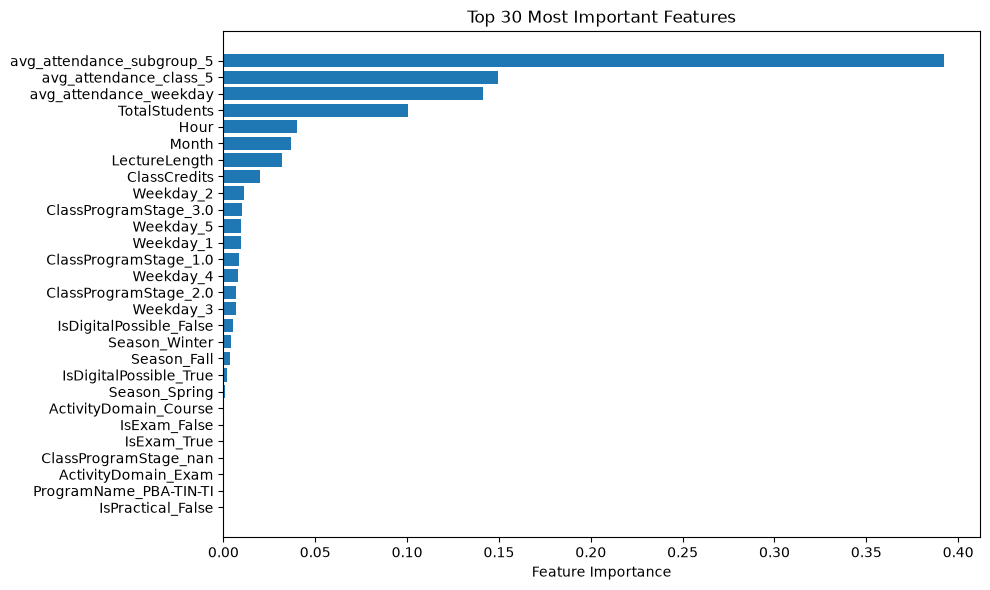

In [ ]:
import matplotlib.pyplot as plt

top_n = 30
plt.figure(figsize=(10,6))
plt.barh(
    feature_importances["Feature"].iloc[:top_n][::-1],
    feature_importances["Importance"].iloc[:top_n][::-1],
    color="tab:blue"
)
plt.xlabel("Feature Importance")
plt.title(f"Top {top_n} Most Important Features")
plt.tight_layout()
plt.show()


## Groepswerken apart bekeken

Groepswerken zitten niet in het model hierboven: de klassieke `AttendanceRate` (aanwezigen / volledige vakpopulatie) valt voor deze vakken structureel te laag uit, omdat het rooster alle subgroepen op elk lesblok vermeldt terwijl studenten in werkelijkheid in vaste kleine groepjes met een eigen verplicht tijdslot zitten.

We bekijken hier eerst hoe laag die naïeve waarde uitkomt, en vergelijken die daarna met de gecorrigeerde aanwezigheid voor één concreet voorbeeld ("System Engineering Lab"), uitgewerkt in `EP3/Analyse/gaining insights/04_system_engineering_lab_wifi_assignment_DEP2_staging.ipynb` door individuele wifi-verbindingen toe te wijzen aan het vaste tijdslot van elke student.

Groepswerk-lessen: 1265 rijen over 9 vakken
Naïeve AttendanceRate - gemiddelde: 27.7%
Naïeve AttendanceRate - mediaan:    18.2%


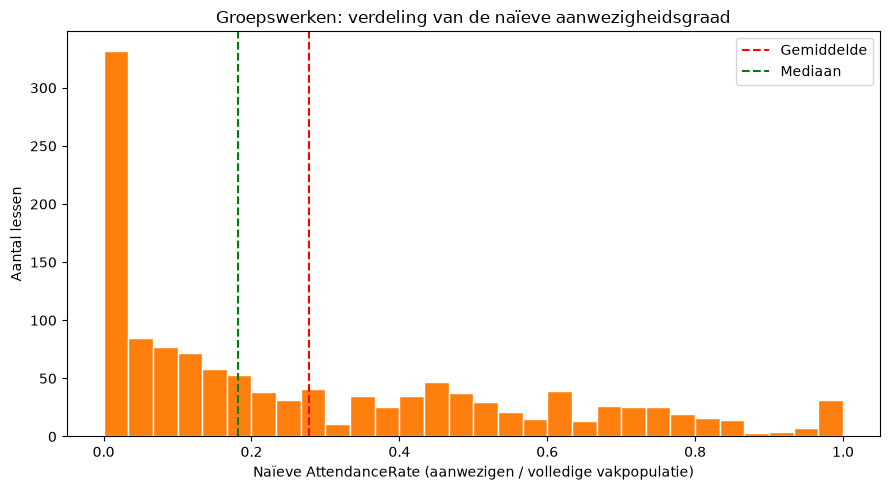

In [ ]:
print(f"Groepswerk-lessen: {len(df_group)} rijen over {df_group['ClassCode'].nunique()} vakken")
print(f"Naïeve AttendanceRate - gemiddelde: {df_group['AttendanceRate'].mean():.1%}")
print(f"Naïeve AttendanceRate - mediaan:    {df_group['AttendanceRate'].median():.1%}")

plt.figure(figsize=(9, 5))
plt.hist(df_group["AttendanceRate"], bins=30, color="tab:orange", edgecolor="white")
plt.axvline(df_group["AttendanceRate"].mean(), color="red", linestyle="--", label="Gemiddelde")
plt.axvline(df_group["AttendanceRate"].median(), color="green", linestyle="--", label="Mediaan")
plt.xlabel("Naïeve AttendanceRate (aanwezigen / volledige vakpopulatie)")
plt.ylabel("Aantal lessen")
plt.title("Groepswerken: verdeling van de naïeve aanwezigheidsgraad")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Vergelijking voor "System Engineering Lab": naïeve AttendanceRate (deze notebook)
# tegenover de gecorrigeerde aanwezigheid per vast tijdslot (afgeleid uit individuele
# wifi-toewijzingen in notebook 04).
sel_naive = df_group[df_group["ClassName"] == "System Engineering Lab"]["AttendanceRate"]
sel_corrected = pd.read_csv(
    "../EP3/Analyse/gaining insights/system_engineering_lab_wifi_inferred_attendance.csv"
)

print("System Engineering Lab")
print(f"  Naïef       - gemiddelde: {sel_naive.mean():.1%}, mediaan: {sel_naive.median():.1%} (n={len(sel_naive)} lesblokken)")
print(f"  Gecorrigeerd - gemiddelde: {sel_corrected['AttendanceRate'].mean():.1%}, mediaan: {sel_corrected['AttendanceRate'].median():.1%} (n={len(sel_corrected)} sessies)")

System Engineering Lab


  Naïef       - gemiddelde: 25.0%, mediaan: 18.5% (n=539 lesblokken)
  Gecorrigeerd - gemiddelde: 67.9%, mediaan: 85.0% (n=36 sessies)


**Interpretatie**: de naïeve AttendanceRate onderschat de werkelijke aanwezigheid bij groepswerken sterk (voor System Engineering Lab: ~25% naïef tegenover ~68% gecorrigeerd). Deze correctie is enkel manueel uitgewerkt voor System Engineering Lab, als illustratie van de omvang van het effect - niet (nog) voor de overige groepswerkvakken. Voor die andere vakken tonen we hierboven dus enkel de naïeve waarde, met het besef dat die een ondergrens is en geen absolute waarheid.